In [1]:
!pip install ipywidgets
!pip install pygraphviz
!apt-get install -qq -y graphviz graphviz-dev && pip install -qq pydot

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 33.5 MB/s eta 0:00:00
Selecting previously unselected package libatk1.0-data.
(Reading database ... 121026 files and directories currently installed.)
Preparing to unpack .../00-libatk1.0-data_2.36.0-3build1_all.deb ...
Unpacking libatk1.0-data (2.36.0-3build1) ...
Selecting previously unselected package libatk1.0-0:amd64.
Preparing to unpack .../01-libatk1.0-0_2.36.0-3build1_amd64.deb ...
Unpacking libatk1.0-0:amd64 (2.36.0-3build1) ...
Selecting previously unselected package libgtk2.0-common.
Preparing to unpack .../02-libgtk2.0-common_2.24.33-2ubuntu2.1_all.deb ...
Unpacking libgtk2.0-common (2.24.33-2ubuntu2.1) ...
Selecting previously unselected package libxcomposite1:amd64.
Preparing to unpack .../03-libxcomposite1_1%3a0.4.5-1build2_amd64.deb ...
Unpacking libxcomposite1:amd64 (1:0.4.5-1build2) ...
Selecting previously unselected package libgtk2.0-0:amd64.
Preparing to unpack .../04-libgtk2.0-0_2.24.33-2ubuntu2.1_amd64.deb ..

In [2]:
## -- System dependencies --
import sys, os, gc
import torch

## -- Device-Agnostic (GPU/CPU) --
def get_system_info():
    if torch.cuda.is_available():
        return f"GPU: {torch.cuda.get_device_name(0)}"
    else:
        return f"CPU: {os.cpu_count()}"

get_system_info()

'CPU: 4'

In [3]:
## -- keras library --
try:
    import tensorflow as tf
except:
    !uv pip install tensorflow
    import tensorflow as tf

from tensorflow.keras.utils import FeatureSpace
from tensorflow.keras.utils import plot_model
# os.environ["KERAS_BACKEND"] = "tensorflow"

In [4]:
## -- Data Manipulation --
import numpy as np, pandas as pd, random

## -- Visualization --
from IPython.display import display, Image
import matplotlib.pyplot as plt
import seaborn as sns

## -- Functional Tools --
import shutil
import itertools
from tqdm import tqdm
from time import time, sleep

from sklearn.utils.class_weight import compute_class_weight
from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay
from sklearn.model_selection import KFold, StratifiedKFold, train_test_split
from sklearn.metrics import roc_auc_score, PredictionErrorDisplay, RocCurveDisplay
from sklearn.preprocessing import StandardScaler, LabelEncoder, TargetEncoder as sklearnTE

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer, MissingIndicator, SimpleImputer

import warnings
warnings.simplefilter('ignore')
warnings.filterwarnings('ignore')

In [5]:
## -- Set Configuration --
# sklearn.set_config(transform_output="pandas")
# pd.options.mode.copy_on_write = True
pd.set_option("display.max_columns", 1000)
sns.set_style("whitegrid")
# plt.style.use('ggplot')

# plt.rcParams['axes.prop_cycle'] = cycler(color=['red', 'green', 'blue'])
plt.rcParams.update({
    # "figure.facecolor": '#0f0f1a', # Outer panel (figure)
    # "axes.facecolor":   '#1a1a2e', # Inner panel (image)
    # "axes.edgecolor":   '#444466',
    # "axes.labelcolor":  '#e0e0ff',
    # "text.color":       'lightblue',
    # "xtick.color":      '#e0e0ff',
    # "ytick.color":      '#e0e0ff',
    # "grid.color":       '#2a2a4a',
    # "grid.alpha":       0.5,
    "font.family":      'monospace',
})

PALETTE = ['c', 'r', 'darkorange', '#3A86FF', 'y']
sns.set_palette(PALETTE)
cmap = sns.diverging_palette(0, 230, 90, 60, as_cmap=True)

## -- Set Global Seed --
CFG = {
    'FOLDS':   5,
    'SEED':    42,
    'GREEN':  '\033[32m',
    'YELLOW': '\033[33m',
    'RESET':  '\033[0m'
}

print(f"CLASSIC {CFG['GREEN']} GREEN {CFG['RESET']} {CFG['YELLOW']} YELLOW {CFG['RESET']}")

CLASSIC  GREEN   YELLOW 


In [6]:
## -- ⚠️ IMPORTANT: SELECT PLATFORM ⚠️ --
PLATFORM = "kaggle" # -> 'colab' 'kaggle'

if PLATFORM == "kaggle":
    PATH = "/kaggle/input/competitions/playground-series-s6e8/"
    submit = pd.read_csv(PATH+'sample_submission.csv')
    train = pd.read_csv(PATH+'train.csv')
    test = pd.read_csv(PATH+'test.csv')

    ORIG_PATH = "/kaggle/input/datasets/jimarahman/smartphone-usage-and-addiction-analysis-dataset/"
    orig = pd.read_csv(ORIG_PATH+"Smartphone_Usage_And_Addiction_Analysis_7500_Rows.csv")
elif PLATFORM == 'colab':
    from google.colab import drive
    drive.mount('/content/drive')

    PATH = "/content/drive/MyDrive/-- shared_notebooks --/Ps6e8 | Phone Addiction/_phone_addiction_data/"
    submit = pd.read_csv(PATH+"sample_submission.csv")
    train = pd.read_csv(PATH+"train.csv")
    test = pd.read_csv(PATH+"test.csv")
    orig = pd.read_csv(PATH+"Smartphone_Usage_And_Addiction_Analysis_7500_Rows.csv")

## ----------------------------------------------------------------------------------------

ID      = "id"
TARGET  = "addicted_label"
OBJECTS = train.select_dtypes(include=["object", "category"]).columns.tolist()

CATS = [c for c in OBJECTS if c not in [TARGET, ID]]
NUMS = [c for c in train.columns if c not in CATS+[TARGET, ID]]
BASE = NUMS + CATS

for (name, df) in {"Train": train, "Test": test , "Orig": orig}.items():
    print(f"{name} shape: {df.shape}")

print(f"\nTotal Numerical: {len(NUMS)}")
print(f"Total Categorical: {len(CATS)}")
print(f"Total base features: {len(BASE)}")

Train shape: (691369, 14)
Test shape: (296302, 13)
Orig shape: (7500, 16)

Total Numerical: 9
Total Categorical: 3
Total base features: 12


In [7]:
display(train.head())
train.info()

,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,addicted_label
0,0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,Male,Medium,No,1
1,1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,Female,Medium,No,0
2,2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,Female,Low,Yes,0
3,3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,Other,Low,NaN,1
4,4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,Female,Medium,No,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 691369 entries, 0 to 691368
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       691369 non-null  int64  
 1   age                      662440 non-null  float64
 2   daily_screen_time_hours  595515 non-null  float64
 3   social_media_hours       557374 non-null  float64
 4   gaming_hours             564548 non-null  float64
 5   work_study_hours         639851 non-null  float64
 6   sleep_hours              646889 non-null  float64
 7   notifications_per_day    623785 non-null  float64
 8   app_opens_per_day        610659 non-null  float64
 9   weekend_screen_time      579306 non-null  float64
 10  gender                   662335 non-null  object 
 11  stress_level             636221 non-null  object 
 12  academic_work_impact     647145 non-null  object 
 13  addicted_label           691369 non-null  int64  
dtypes: f

In [8]:
train.describe().T

,count,mean,std,min,25%,50%,75%,max
id,691369.0,345684.000000,199581.183466,0.00,172842.00,345684.00,518526.00,691368.00
age,662440.0,26.615408,5.153162,18.00,22.00,27.00,31.00,35.00
daily_screen_time_hours,595515.0,7.640865,2.721446,0.50,5.48,7.77,9.84,15.00
social_media_hours,557374.0,2.471038,1.316137,0.00,1.45,2.31,3.37,8.00
gaming_hours,564548.0,1.459265,0.934552,0.00,0.70,1.33,2.09,4.00
work_study_hours,639851.0,2.366971,1.258797,0.00,1.36,2.20,3.20,6.00
sleep_hours,646889.0,6.804334,1.234512,4.50,5.78,6.80,7.87,9.00
notifications_per_day,623785.0,145.894900,65.917556,20.00,93.00,150.00,204.00,250.00
app_opens_per_day,610659.0,102.636781,48.093970,15.00,64.00,104.00,145.00,180.00
weekend_screen_time,579306.0,9.479866,2.856006,0.51,7.28,9.58,11.75,17.56


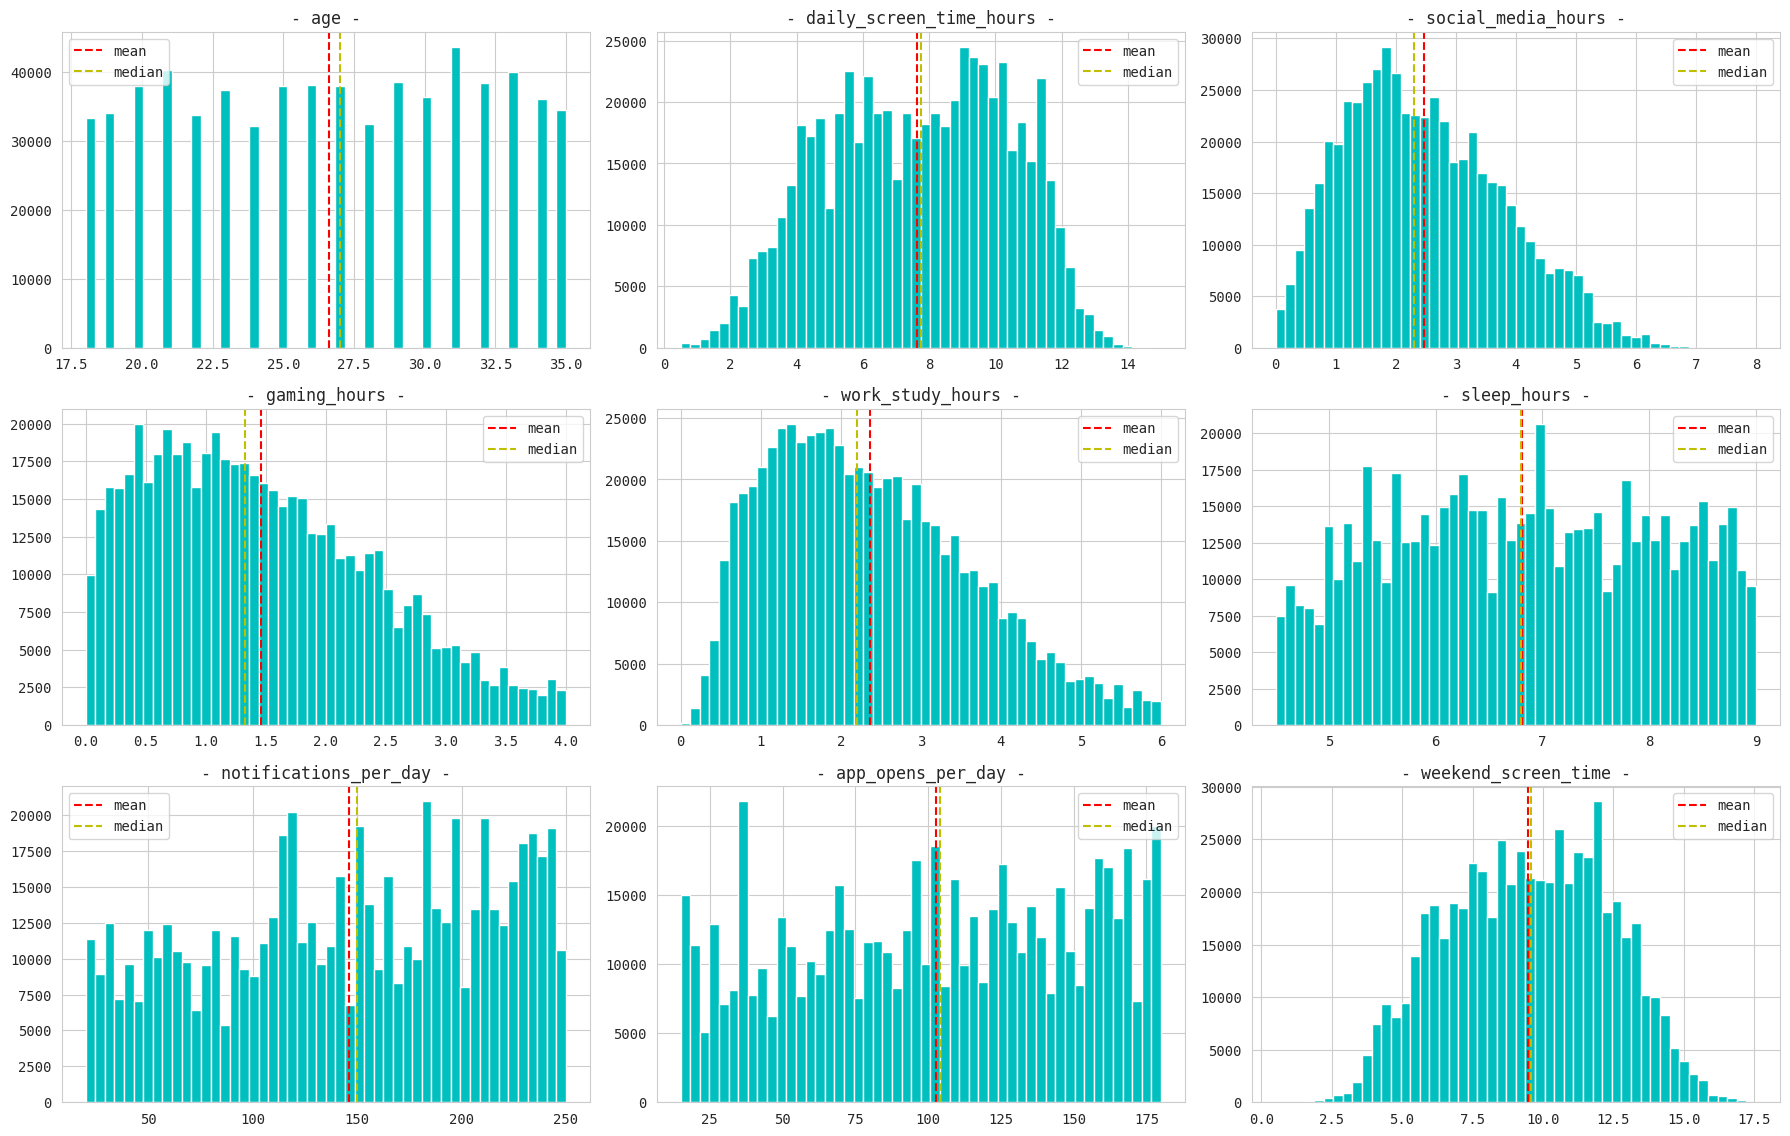

In [9]:
plt.figure(figsize=(18, 15))
for i, col in enumerate(NUMS):
    plt.subplot(4, 3, i+1)
    ax = plt.hist(train[col], bins=50)
    plt.axvline(x=train[col].mean(), color='r', linestyle='--', label='mean')
    plt.axvline(x=train[col].median(), color='y', linestyle='--', label='median')
    plt.title(f"- {col} -")
    plt.legend()

plt.tight_layout()
plt.show()

In [10]:
## -- Unique value counts for each dataset --
TRAIN_UNIQUE = {}
ORIG_UNIQUE = {}
TEST_UNIQUE = {}

for col in BASE:
    TRAIN_UNIQUE[col] = train[col].nunique()
    ORIG_UNIQUE[col] = orig[col].nunique()
    TEST_UNIQUE[col] = test[col].nunique()

unique_counts_df = pd.concat(
        [pd.DataFrame(TRAIN_UNIQUE, index=['Train']),
         pd.DataFrame(ORIG_UNIQUE, index=['Orig']),
         pd.DataFrame(TEST_UNIQUE, index=['Test'])],
    )

unique_counts_df.T.sort_values(by="Train").style.background_gradient(subset="Train")

,Train,Orig,Test
academic_work_impact,2,2,2
gender,3,3,3
stress_level,3,3,3
age,18,18,18
app_opens_per_day,166,166,166
notifications_per_day,231,231,231
gaming_hours,401,401,401
sleep_hours,451,451,451
work_study_hours,600,551,601
social_media_hours,721,551,703


In [11]:
n_unique = train[BASE].nunique().sort_values()
n_unique

academic_work_impact          2
gender                        3
stress_level                  3
age                          18
app_opens_per_day           166
notifications_per_day       231
gaming_hours                401
sleep_hours                 451
work_study_hours            600
social_media_hours          721
daily_screen_time_hours    1389
weekend_screen_time        1437
dtype: int64

In [12]:
def get_weights(y, y_true, opt='auto'):
    """
    y: Current y labels -> numpy array or series
    y_true: True labels -> numpy array or series
    opt: 'auto' generate weight or pass a custom dict -> label: weight
    """
    if opt != 'auto':
        class_weights = opt
        sample_weights = np.array([class_weights[label] for label in y])
        return class_weights
    else:
        classes_ = np.unique(y_true)
        weights_ = compute_class_weight('balanced', classes=classes_, y=y_true)
        class_weights = dict(zip(classes_, weights_))
        sample_weights = np.array([class_weights[label] for label in y])
        return class_weights

print('- Helper Functions Ready -')

- Helper Functions Ready -


## FEATURE ENGINEERING

In [13]:
## -- EXTRACTIONS & BINNING --
ROUNDS = []
DIGITS = []
E_BINS = []
Q_BINS = []
DROP_COLS = []

round_thresh = 3
digit_thresh = 2

round_thresh, digit_thresh

(3, 2)

In [14]:
# for col in NUMS:
#     # print(f"\nRounding... ", end='')
#     # for r in range(-2, 3):
#     #     r_n = f"{col}_round_{r}"
#     #     print(r_n+', ', end='')
#     #     train[r_n] = train[col].round(r).astype('int32')
#     #     test[r_n]  = test[col].round(r).astype('int32')
#     #     orig[r_n]  = orig[col].round(r).astype('int32')

#     #     ## -- Drop irrelevant features --
#     #     if train[r_n].nunique() < round_thresh or train[r_n].nunique() == train[col].nunique():
#     #         DROP_COLS.append(r_n)
#     #     else:
#     #         ROUNDS.append(r_n)

#     print(f"\nDIGITS... ", end='')
#     for d in range(-3, 3):
#         d_n = f'{col}_digit_{d}'
#         print(d_n+', ', end='')
#         train[d_n] = ((train[col] * 10**d) % 10).fillna(-1).astype('int32')
#         test[d_n]  = ((test[col]  * 10**d) % 10).fillna(-1).astype('int32')
#         orig[d_n]  = ((orig[col]  * 10**d) % 10).fillna(-1).astype('int32')

#         ## -- Drop constant features --
#         if train[d_n].nunique() < digit_thresh:
#             DROP_COLS.append(d_n)
#         else:
#             DIGITS.append(d_n)

#     # print(f"\nCreating value-based E_BINS... ", end='')
#     # for b in [100]:
#     #     b_n = f'{col}_bin_{b}'
#     #     print(b_n+', ', end='')
#     #     train[b_n], edges = pd.cut(train[col], bins=b, retbins=True, include_lowest=True, labels=False)
#     #     test[b_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
#     #     orig[b_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
#     #     E_BINS.append(b_n)

#     # print(f"\nCreating quantile-based Q_BINS... ", end='')
#     # for q in [100]:
#     #     q_n = f'{col}_Qbin_{q}'
#     #     print(q_n+', ', end='')
#     #     train[q_n], edges = pd.qcut(train[col], q=q, retbins=True, duplicates='drop', labels=False)
#     #     test[q_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
#     #     orig[q_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
#     #     Q_BINS.append(q_n)

# print()
# print('='*50)
# print(f'✅ Total ROUNDS: {len(ROUNDS)}')
# print(f"✅ Total DIGITS: {len(DIGITS)}")
# print(f"✅ Total E_BINS: {len(E_BINS)}")
# print(f"✅ Total Q_BINS: {len(Q_BINS)}")

In [15]:
train = train.drop(columns=DROP_COLS)
test  = test.drop(columns=DROP_COLS)
orig  = orig.drop(columns=DROP_COLS)

print(f"Features dropped: {DROP_COLS}")

Features dropped: []


In [16]:
train[ROUNDS+DIGITS+E_BINS+Q_BINS].nunique()

Series([], dtype: float64)

In [17]:
def apply_feature_engineering(df_, num_features_, cat_features_):
    df = df_.copy()

    # num_to_cat = []
    # for col in num_features_:
    #     cat_name = f"{col}_cat"
    #     df[cat_name] = df[col].fillna('NaN').astype(str)
    #     num_to_cat.append(cat_name)

    for c in num_features_:
        for i in [0, 1]:
            df[f"{c}_round{i}"] = df[c].round(i)

    social = df['social_media_hours']
    gaming = df['gaming_hours']
    work = df['work_study_hours']
    daily = df['daily_screen_time_hours']
    sleep = df['sleep_hours']
    weekend = df['weekend_screen_time']
    opens = df['app_opens_per_day']
    notifications = df['notifications_per_day']

    df['total_breakdown_hours'] = social.fillna(0) + gaming.fillna(0) + work.fillna(0)
    df['social_ratio'] = social / (daily + 1e-5)
    df['gaming_ratio'] = gaming / (daily + 1e-5)
    df['work_ratio'] = work / (daily + 1e-5)
    df['unaccounted_screen_time'] = daily - df['total_breakdown_hours']
    df['screen_to_sleep_ratio'] = daily / (sleep + 1e-5)
    df['weekend_vs_daily_ratio'] = weekend / (daily + 1e-5)
    df['app_opens_per_hour'] = opens / (daily + 1e-5)
    df['notifications_per_hour'] = notifications / (daily + 1e-5)

    COMP = ['social_media_hours', 'gaming_hours', 'work_study_hours']
    n_missing_components = df[COMP].isna().sum(axis=1)
    missing_daily = daily.isna()
    known_component_sum = df[COMP].sum(axis=1, min_count=1)
    slack = daily - known_component_sum
    daily_missing_with_components = missing_daily & (n_missing_components == 0)
    one_component_missing = (~missing_daily) & (n_missing_components == 1)
    all_screen_known = (~missing_daily) & (n_missing_components == 0)

    df['ci_daily_lb'] = np.where(daily_missing_with_components, known_component_sum, np.nan)
    df['ci_missing_comp_ub'] = np.where(one_component_missing, slack, np.nan)
    df['ci_missing_comp_mid'] = np.where(one_component_missing, np.clip(slack / 2, 0, None), np.nan)
    df['ci_interval_width'] = np.where(one_component_missing, slack, np.nan)
    df['ci_slack_exact'] = np.where(all_screen_known, slack, np.nan)
    df['ci_case'] = np.select([daily_missing_with_components, one_component_missing], [1.0, 2.0], default=0.0).astype('float32')
    df['ci_n_missing'] = (missing_daily.astype('int8') + n_missing_components).astype('float32')

    df['missing_count'] = df[num_features_+cat_features_].isna().sum(axis=1).astype('float32')

    drop = [c for c in df.columns if df[c].nunique(dropna=False) == 1]
    if drop:
        df.drop(drop, axis=1, inplace=True)

    fe_cols = [c for c in df.columns if c not in BASE]

    if ID in fe_cols:
        fe_cols.remove(ID)
    if TARGET in fe_cols:
        fe_cols.remove(TARGET)

    return df, fe_cols 

train, FE_COLS  = apply_feature_engineering(train, NUMS, CATS)
test, _ = apply_feature_engineering(test, NUMS, CATS)
orig, _ = apply_feature_engineering(orig, NUMS, CATS)

new_cats = [c for c in FE_COLS if c.endswith("_cat")]

# new_cats = ["missing_count", "ci_case", "ci_n_missing"]
# new_cats.extend([
#     c for c in FE_COLS
#     if "_round" in c
#     or c.endswith("_cat")
#     or c.startswith("ci_")
# ])

new_nums = [c for c in FE_COLS if c not in new_cats]

# CATS.extend(new_cats)
# NUMS.extend(new_nums)

display(train[new_cats+new_nums].head())

# train[FE_COLS].nunique().sort_values()


,age_round0,age_round1,daily_screen_time_hours_round0,daily_screen_time_hours_round1,social_media_hours_round0,social_media_hours_round1,gaming_hours_round0,gaming_hours_round1,work_study_hours_round0,work_study_hours_round1,sleep_hours_round0,sleep_hours_round1,notifications_per_day_round0,notifications_per_day_round1,app_opens_per_day_round0,app_opens_per_day_round1,weekend_screen_time_round0,weekend_screen_time_round1,total_breakdown_hours,social_ratio,gaming_ratio,work_ratio,unaccounted_screen_time,screen_to_sleep_ratio,weekend_vs_daily_ratio,app_opens_per_hour,notifications_per_hour,ci_daily_lb,ci_missing_comp_ub,ci_missing_comp_mid,ci_interval_width,ci_slack_exact,ci_case,ci_n_missing,missing_count
0,24.0,24.0,NaN,NaN,2.0,1.8,2.0,1.6,2.0,2.1,7.0,7.5,122.0,122.0,38.0,38.0,9.0,8.6,5.53,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.53,NaN,NaN,NaN,NaN,1.0,1.0,1.0
1,19.0,19.0,6.0,6.0,1.0,1.1,NaN,NaN,3.0,3.0,8.0,8.2,76.0,76.0,19.0,19.0,NaN,NaN,4.11,0.180904,NaN,0.507537,1.86,0.726276,NaN,3.182574,12.730297,NaN,1.86,0.93,1.86,NaN,2.0,1.0,2.0
2,18.0,18.0,5.0,5.1,NaN,NaN,NaN,NaN,NaN,NaN,6.0,6.2,134.0,134.0,60.0,60.0,7.0,7.5,0.00,NaN,NaN,NaN,5.09,0.814399,1.467581,11.787796,26.326078,NaN,NaN,NaN,NaN,NaN,0.0,3.0,3.0
3,21.0,21.0,6.0,6.4,1.0,1.3,1.0,1.4,3.0,3.4,9.0,8.8,112.0,112.0,94.0,94.0,9.0,8.7,6.04,0.196261,0.221183,0.523364,0.38,0.725423,1.348908,14.641722,17.445456,NaN,NaN,NaN,NaN,0.38,0.0,0.0,1.0
4,26.0,26.0,11.0,11.2,2.0,1.9,3.0,2.8,2.0,2.0,5.0,5.2,NaN,NaN,NaN,NaN,13.0,13.4,6.63,0.166964,0.250893,0.174107,4.57,2.133329,1.195535,NaN,NaN,NaN,NaN,NaN,NaN,4.57,0.0,0.0,2.0


In [18]:
## -- Frequency encoding --
FREQ_COLS = []

print(f"\nCreating frequencies... ", end="")
for col in NUMS:
    freq = pd.concat([train[col], test[col], orig[col]]).value_counts(dropna=False, normalize=True) #
    n = f"{col}_FREQ"
    print(n+", ", end="")
    for df in [train, test, orig]:
        df[n] = df[col].map(freq).fillna(0).astype("float32")
    FREQ_COLS.append(n)

print(f"\n✓ Total frequency features: {len(FREQ_COLS)}")

train[NUMS+FREQ_COLS]


Creating frequencies... age_FREQ, daily_screen_time_hours_FREQ, social_media_hours_FREQ, gaming_hours_FREQ, work_study_hours_FREQ, sleep_hours_FREQ, notifications_per_day_FREQ, app_opens_per_day_FREQ, weekend_screen_time_FREQ, 
✓ Total frequency features: 9


,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,age_FREQ,daily_screen_time_hours_FREQ,social_media_hours_FREQ,gaming_hours_FREQ,work_study_hours_FREQ,sleep_hours_FREQ,notifications_per_day_FREQ,app_opens_per_day_FREQ,weekend_screen_time_FREQ
0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,0.046406,0.129266,0.002680,0.002655,0.004208,0.004194,0.005188,0.007454,0.002292
1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,0.049082,0.001613,0.001716,0.187145,0.001559,0.000855,0.007745,0.005633,0.163550
2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,0.047898,0.000713,0.182272,0.187145,0.079680,0.005797,0.002166,0.004077,0.001595
3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,0.057899,0.000820,0.002494,0.002573,0.002378,0.002358,0.008818,0.005310,0.000615
4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,0.054907,0.000480,0.003234,0.001878,0.002928,0.002653,0.102299,0.106931,0.000533
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
691364,22.0,10.78,3.25,1.57,1.65,7.71,86.0,94.0,12.89,0.048841,0.000917,0.002738,0.003255,0.003730,0.003061,0.002960,0.005310,0.001807
691365,20.0,3.45,1.86,0.89,0.30,6.59,221.0,42.0,8.47,0.054722,0.001172,0.003309,0.002263,0.000501,0.003874,0.005318,0.009931,0.002690
691366,NaN,NaN,NaN,NaN,2.06,6.16,NaN,86.0,7.79,0.046291,0.129266,0.182272,0.187145,0.003060,0.001770,0.102299,0.002160,0.001274
691367,22.0,11.78,3.69,0.23,1.35,5.53,171.0,62.0,7.71,0.048841,0.001420,0.001785,0.002101,0.003872,0.001106,0.002876,0.002794,0.001712


In [19]:
## -- Cyclic encoding --
CYCLICS = []
cy_cols = [c for c in train.columns if c.endswith("_hours")]

for col in tqdm(cy_cols):
    for p in [12, 24]:
        n_s = f"{col}_sin_{p}"

        train[n_s] = np.sin(2 * np.pi * train[col] / p).astype('float32')
        orig[n_s]  = np.sin(2 * np.pi * orig[col] / p).astype('float32')
        test[n_s]  = np.sin(2 * np.pi * test[col] / p).astype('float32')
        CYCLICS.append(n_s)

        # n_c = f"{col}_cos_{p}"
        # train[n_c] = np.cos(2 * np.pi * train[col] / p).astype('float32')
        # test[n_c] = np.cos(2 * np.pi * test[col] / p).astype('float32')
        # orig[n_c] = np.cos(2 * np.pi * orig[col] / p).astype('float32')
        # CYCLICS.append(n_c)

# NUMS.extend(CYCLICS)

print(f"Cylcic Features created: {len(CYCLICS)}")
print(train[CYCLICS].describe().T)

train[CYCLICS].head()

100%|██████████| 6/6 [00:00<00:00, 17.62it/s]


Cylcic Features created: 12
                                   count      mean       std       min  \
daily_screen_time_hours_sin_12  595515.0 -0.236168  0.669038 -1.000000   
daily_screen_time_hours_sin_24  595515.0  0.694852  0.308752 -0.707107   
social_media_hours_sin_12       557374.0  0.749730  0.248776 -0.866025   
social_media_hours_sin_24       557374.0  0.565418  0.249960  0.000000   
gaming_hours_sin_12             564548.0  0.605986  0.297661  0.000000   
gaming_hours_sin_24             564548.0  0.360581  0.215976  0.000000   
work_study_hours_sin_12         639851.0  0.751345  0.235980  0.000000   
work_study_hours_sin_24         639851.0  0.547345  0.242554  0.000000   
sleep_hours_sin_12              646889.0 -0.328998  0.522602 -1.000000   
sleep_hours_sin_24              646889.0  0.927656  0.080077  0.707107   
total_breakdown_hours_sin_12    691369.0  0.153326  0.713027 -1.000000   
total_breakdown_hours_sin_24    691369.0  0.795909  0.221083 -0.621148   

         

,daily_screen_time_hours_sin_12,daily_screen_time_hours_sin_24,social_media_hours_sin_12,social_media_hours_sin_24,gaming_hours_sin_12,gaming_hours_sin_24,work_study_hours_sin_12,work_study_hours_sin_24,sleep_hours_sin_12,sleep_hours_sin_24,total_breakdown_hours_sin_12,total_breakdown_hours_sin_24
0,NaN,NaN,0.818150,0.460974,0.739631,0.404344,0.893371,0.524729,-0.692143,0.927836,0.243615,0.992439
1,0.015707,0.999969,0.535827,0.278991,NaN,NaN,0.999877,0.712638,-0.917755,0.835807,0.835807,0.880063
2,0.458650,0.971755,NaN,NaN,NaN,NaN,NaN,NaN,-0.130526,0.997859,0.000000,0.000000
3,-0.218143,0.993961,0.612907,0.323917,0.676876,0.363251,0.982287,0.770513,-0.996917,0.734322,-0.020942,0.999945
4,-0.406737,0.207912,0.830012,0.470242,0.995056,0.671074,0.852640,0.488621,0.382683,0.980785,-0.323917,0.986429


In [20]:
# def add_frequency_condition(df1, cols, thresh=5):
#     df = df1.copy()
#     for c in cols:
#         v_counts = df[c].value_counts()
#         to_replace = v_counts[v_counts <= thresh].index
#         df[c] = np.where(df[c].isin(to_replace), -1, df[c])

#     return df

# train = add_frequency_condition(train, DIGITS+ROUNDS, thresh=5)
# test  = add_frequency_condition(test,  DIGITS+ROUNDS, thresh=5)
# orig  = add_frequency_condition(orig,  DIGITS+ROUNDS, thresh=5)

# print(f"Frequency threshold imputed!")

In [21]:
# train["orig_preds"] = np.load(
#     "/kaggle/input/datasets/sylvesterdalmeida/ps6e8-original-prediction/ag_best_addicted_label_train.npy"
# )

# test["orig_preds"]  = np.load(
#     "/kaggle/input/datasets/sylvesterdalmeida/ps6e8-original-prediction/ag_best_addicted_label_test.npy"
# )

In [22]:
from sklearn.base import BaseEstimator, TransformerMixin ## ===== Target/CategoryMean ENCODERS =====

class customTE(BaseEstimator, TransformerMixin):
    """
    Target Encoder that supports multiple aggregation functions,
    internal cross-validation for leakage prevention, and smoothing.

    Parameters
    ----------
    cols_to_encode : list of str
        List of column names to be target encoded.

    aggs : list of str, default=['mean']
        List of aggregation functions to apply. Any function accepted by
        pandas' `.agg()` method is supported, such as:
        'mean', 'std', 'var', 'min', 'max', 'skew', 'nunique',
        'count', 'sum', 'median'.
        Smoothing is applied only to the 'mean' aggregation.

    cv : int, default=5
        Number of folds for cross-validation in fit_transform.

    smooth : float or 'auto', default='auto'
        The smoothing parameter `m`. A larger value puts more weight on the
        global mean. If 'auto', an empirical Bayes estimate is used.

    drop_original : bool, default=False
        If True, the original columns to be encoded are dropped.
    """
    def __init__(self, cols_to_encode, aggs=['mean'], cv=5, smooth='auto', drop_original=False):
        self.cols_to_encode = cols_to_encode
        self.aggs = aggs
        self.cv = cv
        self.smooth = smooth
        self.drop_original = drop_original
        self.mappings_ = {}
        self.global_stats_ = {}

    def fit(self, X, y):
        """
        Learn mappings from the entire dataset.
        These mappings are used for the transform method on validation/test data.
        """
        temp_df = X.copy()
        temp_df['target'] = y

        # Learn global statistics for each aggregation
        for agg_func in self.aggs:
            self.global_stats_[agg_func] = y.agg(agg_func)

        # Learn category-specific mappings
        for col in self.cols_to_encode:
            self.mappings_[col] = {}
            for agg_func in self.aggs:
                mapping = temp_df.groupby(col)['target'].agg(agg_func)
                self.mappings_[col][agg_func] = mapping

        return self

    def transform(self, X):
        """
        Apply learned mappings to the data.
        Unseen categories are filled with global statistics.
        """
        X_transformed = X.copy()
        for col in self.cols_to_encode:
            for agg_func in self.aggs:
                new_col_name = f"TE_{col}_{agg_func}"
                map_series = self.mappings_[col][agg_func]
                X_transformed[new_col_name] = X[col].map(map_series)
                X_transformed[new_col_name].fillna(self.global_stats_[agg_func], inplace=True)

        if self.drop_original:
            X_transformed.drop(columns=self.cols_to_encode, inplace=True)

        return X_transformed

    def fit_transform(self, X, y):
        """
        Fit and transform the data using internal cross-validation to prevent leakage.
        """
        # First, fit on the entire dataset to get global mappings for transform method
        self.fit(X, y)

        # Initialize an empty DataFrame to store encoded features
        encoded_features = pd.DataFrame(index=X.index)

        kf = KFold(n_splits=self.cv, shuffle=True, random_state=42)

        for train_idx, val_idx in kf.split(X, y):
            X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
            X_val = X.iloc[val_idx]

            temp_df_train = X_train.copy()
            temp_df_train['target'] = y_train

            for col in self.cols_to_encode:
                # --- Calculate mappings only on the training part of the fold ---
                for agg_func in self.aggs:
                    new_col_name = f"TE_{col}_{agg_func}"

                    # Calculate global stat for this fold
                    fold_global_stat = y_train.agg(agg_func)

                    # Calculate category stats for this fold
                    mapping = temp_df_train.groupby(col)['target'].agg(agg_func)

                    # --- Apply smoothing only for 'mean' aggregation ---
                    if agg_func == 'mean':
                        counts = temp_df_train.groupby(col)['target'].count()

                        m = self.smooth
                        if self.smooth == 'auto':
                            # Empirical Bayes smoothing
                            variance_between = mapping.var()
                            avg_variance_within = temp_df_train.groupby(col)['target'].var().mean()
                            if variance_between > 0:
                                m = avg_variance_within / variance_between
                            else:
                                m = 0  # No smoothing if no variance between groups

                        # Apply smoothing formula
                        smoothed_mapping = (counts * mapping + m * fold_global_stat) / (counts + m)
                        encoded_values = X_val[col].map(smoothed_mapping)
                    else:
                        encoded_values = X_val[col].map(mapping)

                    # Store encoded values for the validation fold
                    encoded_features.loc[X_val.index, new_col_name] = encoded_values.fillna(fold_global_stat)

        # Merge with original DataFrame
        X_transformed = X.copy()
        for col in encoded_features.columns:
            X_transformed[col] = encoded_features[col]

        if self.drop_original:
            X_transformed.drop(columns=self.cols_to_encode, inplace=True)

        return X_transformed


class CategoryMeanTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, cat_cols=None):
        self.cat_cols = cat_cols
        self.mappings_ = {}
    def fit(self, X, y):
        X = X.copy()
        if self.cat_cols is None:
            self.cat_cols = X.select_dtypes(include=['category']).columns.tolist()
        self.mappings_ = {}
        for col in self.cat_cols:
            df_temp = pd.DataFrame({col: X[col], 'y': y})
            group_means = df_temp.groupby(col, dropna=False)['y'].mean()
            sorted_categories = group_means.sort_values().index
            self.mappings_[col] = {cat: i for i, cat in enumerate(sorted_categories)}
        return self

    def transform(self, X, y=None):
        X = X.copy()
        for col, mapping in self.mappings_.items():
            if col in X.columns:
                X[col] = X[col].map(mapping)
        return X

In [23]:
def original_TE(
    orig: pd.DataFrame,
    df: pd.DataFrame,
    features: list=None,
    target: str=None,
    aggs: list=None,
    fill_nan: bool=False,
):

    if features is None or len(features) == 0:
        return df.copy()

    if aggs is None or len(aggs) == 0:
        return df.copy()

    X_df = df.copy()

    orig_cols = []
    maps = {}

    valid_features = [col for col in features if col in orig.columns]

    pbar = tqdm(valid_features)
    for col in pbar:
        for agg_ in aggs:
            agg_key = agg_.lower()
            new_col = f"oTE_{col}_{agg_key}"
            pbar.set_description(f"Augmenting {col}")
            map_key = (col, agg_key)
            if map_key not in maps:
                try:
                    if agg_key == 'mean':
                        map_df = (orig.groupby(col)[target].mean().reset_index(name=new_col))
                    elif agg_key == 'median':
                        map_df = (orig.groupby(col)[target].median().reset_index(name=new_col))
                    elif agg_key == 'count':
                        map_df = (orig.groupby(col).size().reset_index(name=new_col)) #.astype('int32')
                    elif agg_key == 'nunique':
                        map_df = (orig.groupby(col)[target].nunique().reset_index(name=new_col)) #.astype('int32')
                    elif agg_key == 'std':
                        map_df = (orig.groupby(col)[target].std().reset_index(name=new_col))
                    elif agg_key == 'skew':
                        map_df = (orig.groupby(col)[target].skew().reset_index(name=new_col))
                    elif agg_key == 'max':
                        map_df = (orig.groupby(col)[target].max().reset_index(name=new_col))
                    elif agg_key == 'min':
                        map_df = (orig.groupby(col)[target].min().reset_index(name=new_col))
                    else:
                        continue
                except Exception as e:
                    print(f"Warning: failed to create map for col={col}, agg={agg_}: {e}")
                    continue

                maps[map_key] = map_df

            map_df = maps.get(map_key)
            if map_df is None:
                continue

            # Merge maps into each split
            X_df = X_df.merge(map_df, on=col, how='left')

            orig_cols.append(new_col)

        pbar.set_description(f"Original augment complete!")

    global_mean   = orig[target].mean()
    global_median = orig[target].median()

    def fill_conditionally(df):
        for c in orig_cols:
            if c.endswith(('_mean', '_max', '_min')):
                df[c] = df[c].fillna(global_mean)
            elif c.endswith('_median'):
                df[c] = df[c].fillna(global_median)
            else:
                df[c] = df[c].fillna(0)
        return df

    if fill_nan:
        X_df = fill_conditionally(X_df)

    return X_df, orig_cols

print("-- Data augment function ready! --")

-- Data augment function ready! --


In [24]:
# ## -- "mean", "median", "count", "std", "skew", "nunique", "max", "min"
# orig_aggs = ["mean", "count"]

# train, orig_cols = original_TE(
#     orig,
#     train,
#     features=BASE,
#     target=TARGET,
#     aggs=orig_aggs,
#     fill_nan=True,
# )

# test, _ = original_TE(
#     orig,
#     test,
#     features=BASE,
#     target=TARGET,
#     aggs=orig_aggs,
#     fill_nan=True,
# )

# train[orig_cols][:10].T

In [25]:
# ## -- Apply log transformation --
# for df in [train, test, orig]:
#     df['log_RaceProgress'] = np.log(df['RaceProgress'])
#     df['log_LapTime_s'] = np.log(df['LapTime (s)'])

# log_features = ['log_RaceProgress', 'log_LapTime_s']

# ## -- Absolute values --
# for df in [train, test, orig]:
#     df['abs_lap_delta'] = np.abs(df['LapTime_Delta'])
#     df['abs_degrade'] = np.abs(df['Cumulative_Degradation'])

# abs_features = ['abs_lap_delta', 'abs_degrade']

# plt.figure(figsize=(18, 8))
# for i, col in enumerate(log_features+abs_features):
#     plt.subplot(2, 2, i+1)
#     plt.hist(train[col], bins=50)
#     # orig[col].plot.hist()
#     plt.axvline(x=orig[col].mean(), color='r', linestyle='--', label='mean')
#     plt.axvline(x=orig[col].median(), color='g', linestyle='--', label='median')
#     plt.title(f'{col}')
#     plt.legend()

# plt.tight_layout()
# plt.show()

In [26]:
# ## -- Lag/Differential features --
# # ['Delta_lag1', 'Delta_roll3_mean', 'Deg_diff', 'TyreLife_growth', 'LapTime_lag1', 'LapTime_diff']

# for df in [train, test, orig]:
#     df['Degrade_diff'] = df['Cumulative_Degradation'].diff()
#     df['LapTime_diff'] = df['LapTime (s)'].diff()
#     df['Delta_roll_3'] = df['LapTime_Delta'].rolling(3).mean()
#     # df['Delta_roll_3_LapNum'] = df['LapTime_Delta'].rolling(3).mean()
#     df['LapTime_delta_shift'] = df['LapTime (s)'].shift(3) #'infer, 'D'

# lag_features = [
#     'Degrade_diff',
#     'LapTime_diff',
#     'Delta_roll_3',
#     # 'Delta_roll_3_LapNum',
#     'LapTime_delta_shift'
# ]

# train[lag_features].describe()
# # train.head()

In [27]:
FEATURES = [c for c in train.columns if c not in [ID, TARGET]]

combined = pd.concat([train, test, orig])

combined[CATS] = combined[CATS].fillna("_empty_")
## ------------------------------------------------------------
# ## -- Duplicate Nums as Cats --
# CATS_2 = []
# for c in tqdm(NUMS):
#     n = f"cat_{c}"
#     combined[n] = combined[c].factorize()[0]
#     CATS_2.append(n)
# # CATS.extend(CATS_2)
# FEATURES.extend(CATS_2)
## ------------------------------------------------------------
# ## -- Factorize CATS --
# for c in CATS:
#     combined[c] = combined[c].factorize()[0]
#     # combined[c] = combined[c].astype('category')

train = combined.iloc[:len(train)][FEATURES+[TARGET]]
test  = combined.iloc[len(train):len(train)+len(test)][FEATURES]
orig  = combined.iloc[len(train)+len(test):]

del combined
print("Label encoding complete!")
print("Total Features:", len(FEATURES))

train

Label encoding complete!
Total Features: 68


,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,age_round0,age_round1,daily_screen_time_hours_round0,daily_screen_time_hours_round1,social_media_hours_round0,social_media_hours_round1,gaming_hours_round0,gaming_hours_round1,work_study_hours_round0,work_study_hours_round1,sleep_hours_round0,sleep_hours_round1,notifications_per_day_round0,notifications_per_day_round1,app_opens_per_day_round0,app_opens_per_day_round1,weekend_screen_time_round0,weekend_screen_time_round1,total_breakdown_hours,social_ratio,gaming_ratio,work_ratio,unaccounted_screen_time,screen_to_sleep_ratio,weekend_vs_daily_ratio,app_opens_per_hour,notifications_per_hour,ci_daily_lb,ci_missing_comp_ub,ci_missing_comp_mid,ci_interval_width,ci_slack_exact,ci_case,ci_n_missing,missing_count,age_FREQ,daily_screen_time_hours_FREQ,social_media_hours_FREQ,gaming_hours_FREQ,work_study_hours_FREQ,sleep_hours_FREQ,notifications_per_day_FREQ,app_opens_per_day_FREQ,weekend_screen_time_FREQ,daily_screen_time_hours_sin_12,daily_screen_time_hours_sin_24,social_media_hours_sin_12,social_media_hours_sin_24,gaming_hours_sin_12,gaming_hours_sin_24,work_study_hours_sin_12,work_study_hours_sin_24,sleep_hours_sin_12,sleep_hours_sin_24,total_breakdown_hours_sin_12,total_breakdown_hours_sin_24,addicted_label
0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,Male,Medium,No,24.0,24.0,NaN,NaN,2.0,1.8,2.0,1.6,2.0,2.1,7.0,7.5,122.0,122.0,38.0,38.0,9.0,8.6,5.53,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.53,NaN,NaN,NaN,NaN,1.0,1.0,1.0,0.046406,0.129266,0.002680,0.002655,0.004208,0.004194,0.005188,0.007454,0.002292,NaN,NaN,0.818150,0.460974,0.739631,0.404344,0.893371,0.524729,-0.692143,0.927836,0.243615,0.992439,1.0
1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,Female,Medium,No,19.0,19.0,6.0,6.0,1.0,1.1,NaN,NaN,3.0,3.0,8.0,8.2,76.0,76.0,19.0,19.0,NaN,NaN,4.11,0.180904,NaN,0.507537,1.86,0.726276,NaN,3.182574,12.730297,NaN,1.86,0.93,1.86,NaN,2.0,1.0,2.0,0.049082,0.001613,0.001716,0.187145,0.001559,0.000855,0.007745,0.005633,0.163550,0.015707,0.999969,0.535827,0.278991,NaN,NaN,0.999877,0.712638,-0.917755,0.835807,0.835807,0.880063,0.0
2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,Female,Low,Yes,18.0,18.0,5.0,5.1,NaN,NaN,NaN,NaN,NaN,NaN,6.0,6.2,134.0,134.0,60.0,60.0,7.0,7.5,0.00,NaN,NaN,NaN,5.09,0.814399,1.467581,11.787796,26.326078,NaN,NaN,NaN,NaN,NaN,0.0,3.0,3.0,0.047898,0.000713,0.182272,0.187145,0.079680,0.005797,0.002166,0.004077,0.001595,0.458650,0.971755,NaN,NaN,NaN,NaN,NaN,NaN,-0.130526,0.997859,0.000000,0.000000,0.0
3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,Other,Low,_empty_,21.0,21.0,6.0,6.4,1.0,1.3,1.0,1.4,3.0,3.4,9.0,8.8,112.0,112.0,94.0,94.0,9.0,8.7,6.04,0.196261,0.221183,0.523364,0.38,0.725423,1.348908,14.641722,17.445456,NaN,NaN,NaN,NaN,0.38,0.0,0.0,1.0,0.057899,0.000820,0.002494,0.002573,0.002378,0.002358,0.008818,0.005310,0.000615,-0.218143,0.993961,0.612907,0.323917,0.676876,0.363251,0.982287,0.770513,-0.996917,0.734322,-0.020942,0.999945,1.0
4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,Female,Medium,No,26.0,26.0,11.0,11.2,2.0,1.9,3.0,2.8,2.0,2.0,5.0,5.2,NaN,NaN,NaN,NaN,13.0,13.4,6.63,0.166964,0.250893,0.174107,4.57,2.133329,1.195535,NaN,NaN,NaN,NaN,NaN,NaN,4.57,0.0,0.0,2.0,0.054907,0.000480,0.003234,0.001878,0.002928,0.002653,0.102299,0.106931,0.000533,-0.406737,0.207912,0.830012,0.470242,0.995056,0.671074,0.852640,0.488621,0.382683,0.980785,-0.323917,0.986429,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
691364,22.0,10.78,3.25,1.57,1.65,7.71,86.0,94.0,12.89,Male,_empty_,No,22.0,22.0,11.0,10.8,3.0,3.2,2.0,1.6,2.0,1.6,8.0,7.7,86.0,86.0,94.0,94.0,13.0,12.9,6.47,0.301484,0.145640,0.153061,4.31,1.398182,1.195732,8.71

In [28]:
# ## -- Get missing_indicators --

# indicator = MissingIndicator()

# tr = pd.DataFrame(indicator.fit_transform(train[NUMS])).astype('int8')
# tr.columns = ["indicator_" + str(c) for c in tr.columns]
# train = pd.concat([train, tr], axis=1)

# ts = pd.DataFrame(indicator.transform(test[NUMS])).astype('int8')
# ts.columns = ["indicator_" + str(c) for c in ts.columns]
# test = pd.concat([test, ts], axis=1)

# og = pd.DataFrame(indicator.transform(orig[NUMS])).astype('int8')
# og.columns = ["indicator_" + str(c) for c in og.columns]
# orig = pd.concat([orig, og], axis=1)

# indicators = tr.columns.tolist()
# CATS.extend(indicators)
# print(CATS)

# train

In [29]:
FEATURES = [c for c in train.columns if c not in [ID, TARGET]]
print("Total Features:", len(FEATURES))

train

Total Features: 68


,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,age_round0,age_round1,daily_screen_time_hours_round0,daily_screen_time_hours_round1,social_media_hours_round0,social_media_hours_round1,gaming_hours_round0,gaming_hours_round1,work_study_hours_round0,work_study_hours_round1,sleep_hours_round0,sleep_hours_round1,notifications_per_day_round0,notifications_per_day_round1,app_opens_per_day_round0,app_opens_per_day_round1,weekend_screen_time_round0,weekend_screen_time_round1,total_breakdown_hours,social_ratio,gaming_ratio,work_ratio,unaccounted_screen_time,screen_to_sleep_ratio,weekend_vs_daily_ratio,app_opens_per_hour,notifications_per_hour,ci_daily_lb,ci_missing_comp_ub,ci_missing_comp_mid,ci_interval_width,ci_slack_exact,ci_case,ci_n_missing,missing_count,age_FREQ,daily_screen_time_hours_FREQ,social_media_hours_FREQ,gaming_hours_FREQ,work_study_hours_FREQ,sleep_hours_FREQ,notifications_per_day_FREQ,app_opens_per_day_FREQ,weekend_screen_time_FREQ,daily_screen_time_hours_sin_12,daily_screen_time_hours_sin_24,social_media_hours_sin_12,social_media_hours_sin_24,gaming_hours_sin_12,gaming_hours_sin_24,work_study_hours_sin_12,work_study_hours_sin_24,sleep_hours_sin_12,sleep_hours_sin_24,total_breakdown_hours_sin_12,total_breakdown_hours_sin_24,addicted_label
0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,Male,Medium,No,24.0,24.0,NaN,NaN,2.0,1.8,2.0,1.6,2.0,2.1,7.0,7.5,122.0,122.0,38.0,38.0,9.0,8.6,5.53,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.53,NaN,NaN,NaN,NaN,1.0,1.0,1.0,0.046406,0.129266,0.002680,0.002655,0.004208,0.004194,0.005188,0.007454,0.002292,NaN,NaN,0.818150,0.460974,0.739631,0.404344,0.893371,0.524729,-0.692143,0.927836,0.243615,0.992439,1.0
1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,Female,Medium,No,19.0,19.0,6.0,6.0,1.0,1.1,NaN,NaN,3.0,3.0,8.0,8.2,76.0,76.0,19.0,19.0,NaN,NaN,4.11,0.180904,NaN,0.507537,1.86,0.726276,NaN,3.182574,12.730297,NaN,1.86,0.93,1.86,NaN,2.0,1.0,2.0,0.049082,0.001613,0.001716,0.187145,0.001559,0.000855,0.007745,0.005633,0.163550,0.015707,0.999969,0.535827,0.278991,NaN,NaN,0.999877,0.712638,-0.917755,0.835807,0.835807,0.880063,0.0
2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,Female,Low,Yes,18.0,18.0,5.0,5.1,NaN,NaN,NaN,NaN,NaN,NaN,6.0,6.2,134.0,134.0,60.0,60.0,7.0,7.5,0.00,NaN,NaN,NaN,5.09,0.814399,1.467581,11.787796,26.326078,NaN,NaN,NaN,NaN,NaN,0.0,3.0,3.0,0.047898,0.000713,0.182272,0.187145,0.079680,0.005797,0.002166,0.004077,0.001595,0.458650,0.971755,NaN,NaN,NaN,NaN,NaN,NaN,-0.130526,0.997859,0.000000,0.000000,0.0
3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,Other,Low,_empty_,21.0,21.0,6.0,6.4,1.0,1.3,1.0,1.4,3.0,3.4,9.0,8.8,112.0,112.0,94.0,94.0,9.0,8.7,6.04,0.196261,0.221183,0.523364,0.38,0.725423,1.348908,14.641722,17.445456,NaN,NaN,NaN,NaN,0.38,0.0,0.0,1.0,0.057899,0.000820,0.002494,0.002573,0.002378,0.002358,0.008818,0.005310,0.000615,-0.218143,0.993961,0.612907,0.323917,0.676876,0.363251,0.982287,0.770513,-0.996917,0.734322,-0.020942,0.999945,1.0
4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,Female,Medium,No,26.0,26.0,11.0,11.2,2.0,1.9,3.0,2.8,2.0,2.0,5.0,5.2,NaN,NaN,NaN,NaN,13.0,13.4,6.63,0.166964,0.250893,0.174107,4.57,2.133329,1.195535,NaN,NaN,NaN,NaN,NaN,NaN,4.57,0.0,0.0,2.0,0.054907,0.000480,0.003234,0.001878,0.002928,0.002653,0.102299,0.106931,0.000533,-0.406737,0.207912,0.830012,0.470242,0.995056,0.671074,0.852640,0.488621,0.382683,0.980785,-0.323917,0.986429,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
691364,22.0,10.78,3.25,1.57,1.65,7.71,86.0,94.0,12.89,Male,_empty_,No,22.0,22.0,11.0,10.8,3.0,3.2,2.0,1.6,2.0,1.6,8.0,7.7,86.0,86.0,94.0,94.0,13.0,12.9,6.47,0.301484,0.145640,0.153061,4.31,1.398182,1.195732,8.71

# ML TRAINING

In [30]:
# def build_keras_model(
#     feature_space: tf.keras.utils.FeatureSpace = None,
#     layer_units: list = [128, 64, 32],
#     learning_rate: float = 0.01,
#     drop_rate: float = 0.1,
#     activation: str = "relu",
#     l2_reg = tf.keras.regularizers.L2(0.0)
# ):
#     # 1. Retrieve structural components from the globally adapted FeatureSpace
#     dict_inputs = feature_space.get_inputs()
#     encoded_features = feature_space.get_encoded_features()

#     print(f"Dict_input shape: {len(dict_inputs)}", end=" | ")
#     print(f"FS_encoded shape: {encoded_features.shape} +++ Loop model +++")
#     print('-'*90)

#     # 2. Build the Core Deep Neural Network using the Functional API safely
#     # This ensures layers are completely reusable across train/inference topologies
#     x = encoded_features

#     # Clean, dynamic looping over layer configuration list
#     for units in layer_units:
#         x = tf.keras.layers.Dense(
#             units,
#             activation=activation,
#             kernel_regularizer=l2_reg)(x)
#         x = tf.keras.layers.BatchNormalization()(x)
#         x = tf.keras.layers.Dropout(drop_rate)(x)

#     # Final Binary Classification Output Node
#     final_output = tf.keras.layers.Dense(1, activation="sigmoid")(x)

#     train_model = tf.keras.Model(inputs=encoded_features, outputs=final_output)
#     infer_model = tf.keras.Model(inputs=dict_inputs, outputs=final_output)

#     train_model.compile(
#         optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate, weight_decay=0.0),
#         loss="binary_crossentropy",
#         metrics=[tf.keras.metrics.AUC(name="auc")]
#     )

#     return train_model, infer_model

# print("⚙️ Optimized Keras model builder ready ⚙️")

In [31]:
def build_keras_model(
    feature_space: tf.keras.utils.FeatureSpace = None,
    layer_units: list = [128, 64, 32],
    learning_rate: float = 0.01,
    drop_rate: float = 0.1,
    activation: str = "relu",
    l2_reg = tf.keras.regularizers.L2(0.0),
):

    # 1. Setup Inputs
    dict_inputs = feature_space.get_inputs()
    encoded_features = feature_space.get_encoded_features()

    print(f"Dict_Input: {len(dict_inputs)}", end=" | ")
    print(f"FS_Encoded: {encoded_features.shape} +++ Sequential model +++")
    print('-'*90)

    # 2. Create the Sequential model
    outputs = tf.keras.Sequential([
        # keras.Input(shape=shape),
        # Optional: Add BN here if your data isn't pre-scaled
        # keras.layers.BatchNormalization(),

        ## -- 1st Layer --
        tf.keras.layers.Dense(layer_units[0], activation, #use_bias=False,
                              kernel_regularizer=l2_reg),
        tf.keras.layers.BatchNormalization(),
        # tf.keras.layers.Activation('relu'),
        tf.keras.layers.Dropout(drop_rate),

        ## -- 2nd Layer --
        tf.keras.layers.Dense(layer_units[1], activation, #use_bias=False,
                              kernel_regularizer=l2_reg),
        tf.keras.layers.BatchNormalization(),
        # tf.keras.layers.Activation('relu'),
        tf.keras.layers.Dropout(drop_rate),

        ## -- 3rd Layer --
        tf.keras.layers.Dense(layer_units[2], activation, #use_bias=False,
                              kernel_regularizer=l2_reg),
        tf.keras.layers.BatchNormalization(),
        # keras.layers.Activation('relu'),
        tf.keras.layers.Dropout(drop_rate),

        ## -- Output --
        tf.keras.layers.Dense(1, activation="sigmoid")
    ])(encoded_features)

    # Connect everything
    train_model = tf.keras.Model(inputs=encoded_features, outputs=outputs)
    train_model.compile(
        # optimizer=keras.optimizers.Adam(learning_rate, weight_decay=None), # 0.02
        # optimizer=tf.keras.optimizers.RMSprop(learning_rate),
        optimizer=tf.keras.optimizers.Adam(learning_rate, weight_decay=0.0),
        loss="binary_crossentropy",
        metrics=[tf.keras.metrics.AUC(name="auc")]
        )

    infer_model = tf.keras.Model(inputs=dict_inputs, outputs=outputs)

    return train_model, infer_model

print("⚙️ Keras model ready ⚙️")

⚙️ Keras model ready ⚙️


In [32]:
## -- Define CV Trainer --

class TrainerCV:
    def __init__(
        self,
        model_builder,
        model_name: str,
        train_df: pd.DataFrame,
        test_df: pd.DataFrame,
        features: list,
        target: str,
        kfold,
        batch_size: int=32,
        epochs: int=10,
        drop_rate: float=0.1,
        patience: int=3,
        layer_units: list=[128, 64, 32],
        learning_rate: float=0.01,
        activation: str = "relu",
        eval_metric: str="auc",
        use_original: bool=False,
        **kwargs
    ):
        self.model_builder = model_builder
        self.model_name = model_name
        self.train_df = train_df
        self.test_df = test_df
        self.features = features
        self.target = target
        self.kfold = kfold
        self.batch_size = batch_size
        self.epochs = epochs
        self.drop_rate = drop_rate
        self.patience = patience
        self.layer_units = layer_units
        self.learning_rate = learning_rate
        self.activation = activation
        self.eval_metric = eval_metric
        self.use_original = use_original

        self.result = None
        self.oof_preds   = np.zeros(len(train_df))
        self.test_preds  = np.zeros(len(test_df))
        self.fold_scores = []

    def _feature_space_transform(self, train_data, features_adapt, batch_input):
        """Initializes and adapts Keras FeatureSpace globally once."""
        feature_specs = {}
        for col in features_adapt:
            if col in CATS and col in train_data.columns:
                feature_specs[col] = FeatureSpace.string_categorical(num_oov_indices=1)
            else:
                feature_specs[col] = FeatureSpace.float_normalized()

        _fs = FeatureSpace(
            features=feature_specs,
            crosses=[],
            output_mode="concat",
            name="feature_processed",
        )

        ds = tf.data.Dataset.from_tensor_slices(
            (dict(train_data[features_adapt]), train_data[self.target])
        ).batch(batch_input)

        no_labels = ds.map(lambda x, _: x)
        print(f"♨︎ FeatureSpace.adapt() to {len(features_adapt)} features... ", end="")
        
        _fs.adapt(no_labels)
        print(f"☑️ Complete!\n")

        return _fs

    def fit(self):
        print(f"\n===== Starting CV: {self.model_name} | {get_system_info()} =====")
        t0 = time()

        tf.keras.backend.clear_session()
        # --------------------------------------------
        CHECKPOINT = "checkpoints/"
        shutil.rmtree(CHECKPOINT, ignore_errors=True)
        os.makedirs(CHECKPOINT, exist_ok=True)
        # --------------------------------------------

        self.oof_preds = np.zeros(len(self.train_df))
        self.test_preds = np.zeros(len(self.test_df))
        self.oof_scores = []
        self.fold_histories = []

        feature_cols_for_model = list(self.features)

        # Handle optional original table aggregations securely if flags enable them
        if self.use_original and "original_TE" in globals():
            aggs_ = ["mean", "std"]
            X_tr, orig_cols = original_TE(
                orig, self.train_df, target=self.target, features=BASE, aggs=aggs_, fill_nan=True
            )
            x_test, _ = original_TE(
                orig, self.test_df, target=self.target, features=BASE, aggs=aggs_, fill_nan=True
            )
            feature_cols_for_model.extend(orig_cols)
            X = X_tr[feature_cols_for_model].copy()
            X_ts = x_test[feature_cols_for_model].copy()
            y = X_tr[self.target].astype("int8")
        else:
            X = self.train_df[feature_cols_for_model].copy()
            X_ts = self.test_df[feature_cols_for_model].copy()
            y = self.train_df[self.target].astype("int8")

        # Explicit multi-device strategy execution activation
        strategy = tf.distribute.MirroredStrategy()
        GLOBAL_BATCH_SIZE = self.batch_size * strategy.num_replicas_in_sync
        print(f"⚙️ Number of devices: {strategy.num_replicas_in_sync}")

        for idx, (train_idx, val_idx) in enumerate(self.kfold.split(X, y), 1):
            print(f"\n===== Fold {idx}/{self.kfold.n_splits}", end=" | ")

            X_train, X_valid = X.iloc[train_idx].copy(), X.iloc[val_idx].copy()
            y_train, y_valid = y.iloc[train_idx].copy(), y.iloc[val_idx].copy()
            X_test = X_ts.copy()
    
            # --------------------------------------------------------------------
            # ## -- TargetEncoding -> (Scikit-learn) --
            # te_enc1 = sklearnTE(target_type="binary", random_state=0)
            # X_train.loc[:, CATS_2] = te_enc1.fit_transform(X_train[CATS_2], y_train)
            # X_valid.loc[:, CATS_2] = te_enc1.transform(X_valid[CATS_2])
            # X_test.loc[:, CATS_2]  = te_enc1.transform(X_test[CATS_2])

            ## -- TargetEncoding -> Using custom --
            te_enc2 = customTE(new_cats, cv=5, smooth='auto', aggs=['mean', 'std'], drop_original=True)
            X_train = te_enc2.fit_transform(X_train, y_train)
            X_valid = te_enc2.transform(X_valid)
            X_test  = te_enc2.transform(X_test)
            # --------------------------------------------------------------------
            # ---- Imputation ----
            impute_nums = X_train.columns[X_train[X_train.columns].isna().any()].tolist()
            # impute_nums = [c for c in X_train.columns if c not in CATS]

            if impute_nums:
                # # ---- Scaling ----  
                # scaler = StandardScaler() #.set_output(transform="pandas")
                # X_train[impute_nums] = scaler.fit_transform(X_train[impute_nums], y_train)
                # X_valid[impute_nums] = scaler.transform(X_valid[impute_nums])
                # X_test[impute_nums]  = scaler.transform(X_test[impute_nums])

                imputer = SimpleImputer() #.set_output(transform="pandas")
                X_train[impute_nums] = imputer.fit_transform(X_train[impute_nums], y_train)
                X_valid[impute_nums] = imputer.transform(X_valid[impute_nums])
                X_test[impute_nums]  = imputer.transform(X_test[impute_nums])

            # non_binary_cols = [c for c in X_train.columns if X_train[c].nunique() > 2]

            # --------------------------------------------------------------------
            # ---- FeatureSpace Adaptation ----  
            FS_module = self._feature_space_transform(
                pd.concat([X_train, y_train], axis=1),
                X_train.columns.tolist(),
                GLOBAL_BATCH_SIZE,
            )

            # PERFORMANCE FIX: Formulate explicit dictionary naming structures mapping directly into placeholders
            X_train_ds = tf.data.Dataset.from_tensor_slices((dict(X_train), y_train)).batch(GLOBAL_BATCH_SIZE)
            preprocessed_train_ds = (X_train_ds.map(
                lambda x, y: (FS_module(x), y), 
                num_parallel_calls=tf.data.AUTOTUNE
            ).cache().shuffle(buffer_size=len(X_train)).prefetch(tf.data.AUTOTUNE))

            X_val_ds = tf.data.Dataset.from_tensor_slices((dict(X_valid), y_valid)).batch(GLOBAL_BATCH_SIZE)
            preprocessed_val_ds = (X_val_ds.map(
                lambda x, y: (FS_module(x), y), 
                num_parallel_calls=tf.data.AUTOTUNE
            ).cache().prefetch(tf.data.AUTOTUNE))

            # Distribute execution matrices smoothly over available cores
            dist_train_ds = strategy.experimental_distribute_dataset(preprocessed_train_ds)
            dist_valid_ds = strategy.experimental_distribute_dataset(preprocessed_val_ds)

            callbacks = [
                tf.keras.callbacks.EarlyStopping(
                    monitor="val_auc" if self.eval_metric == "auc" else "val_loss",
                    patience=self.patience,
                    restore_best_weights=True,
                ),
                tf.keras.callbacks.ModelCheckpoint(
                    filepath=f"{CHECKPOINT}best_model.model.keras",
                    monitor="val_auc" if self.eval_metric == "auc" else "val_loss",
                    save_best_only=True,
                ),
            ]

            # Wrap model building and compiling inside the active strategy scope block
            # with strategy.scope():
            train_model, infer_model = self.model_builder(
                feature_space=FS_module,
                drop_rate=self.drop_rate,
                layer_units=self.layer_units,
                learning_rate=self.learning_rate,
                activation=self.activation,
            )

            print(f"    🟢 Training Model Graph...")
            history = train_model.fit(
                dist_train_ds,
                validation_data=dist_valid_ds,
                epochs=self.epochs,
                callbacks=callbacks,
                verbose=1,
            )

            self.fold_histories.append(history.history)

            # CACHING INFERENCE CHANNELS: Cache transformed evaluation datasets to save CPU cycles
            X_val_infer_ds = tf.data.Dataset.from_tensor_slices(dict(X_valid))\
                                            .batch(GLOBAL_BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
            X_test_infer_ds = tf.data.Dataset.from_tensor_slices(dict(X_test))\
                                            .batch(GLOBAL_BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

            # HIGH EFFICIENCY PREDICTION: Route raw data dictionaries directly into the inference graph
            # print(f"    🔵 Evaluating Out-of-Fold Predictions...")
            self.oof_preds[val_idx] = infer_model.predict(X_val_infer_ds).ravel()
            
            fold_auc = roc_auc_score(y_valid, self.oof_preds[val_idx])
            self.oof_scores.append(fold_auc)
            print(f"--------> FOLD {idx}/{self.kfold.n_splits} AUC: {fold_auc:.6f}")

            # print(f"    🟡 Calculating Test Inferences...")
            self.test_preds += infer_model.predict(X_test_infer_ds).ravel() / self.kfold.n_splits

            del FS_module, dist_train_ds, dist_valid_ds, X_val_infer_ds, X_test_infer_ds

        # --- Print metrics ----
        print("\n==================================================")
        print(f"{self.kfold.n_splits}-FOLD CV: {self.model_name} | {X_train.shape}")
        print("==================================================")
        for i, s in enumerate(self.oof_scores, 1):
            print(f" • Fold {i} AUC: {s:.6f}")

        oof_AUC = np.round(roc_auc_score(y, self.oof_preds), 6)
        avg_AUC = np.round(np.mean(self.oof_scores), 6)
        std_AUC = np.round(np.std(self.oof_scores), 6)

        print("-------------------------------------------------|")
        print(f"Overall score: {oof_AUC}")
        print(f"Average score: {avg_AUC} ± {std_AUC}")
        print("-------------------------------------------------|")
        print(f"{(time()-t0)/60:.2f} mins\n")

        return {
            'avg_score': avg_AUC,
            'oof_score': oof_AUC,
            'fold_score': self.oof_scores,
            'oof_preds': self.oof_preds,
            'test_preds': self.test_preds,
            'history': self.fold_histories,
        }

print("-- Keras trainer ready! --")

-- Keras trainer ready! --


In [33]:
all_predictions = {}

CFG['FOLDS'] = 5
skf = StratifiedKFold(n_splits=CFG['FOLDS'], shuffle=True, random_state=CFG['SEED'])

USE_FULL_TRAIN = True
x_sample, x_sample2 = train_test_split(train, train_size=0.05, stratify=train[TARGET], random_state=0)
train_data = train.copy() if USE_FULL_TRAIN else x_sample.reset_index(drop=True).copy()

train_data

,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,age_round0,age_round1,daily_screen_time_hours_round0,daily_screen_time_hours_round1,social_media_hours_round0,social_media_hours_round1,gaming_hours_round0,gaming_hours_round1,work_study_hours_round0,work_study_hours_round1,sleep_hours_round0,sleep_hours_round1,notifications_per_day_round0,notifications_per_day_round1,app_opens_per_day_round0,app_opens_per_day_round1,weekend_screen_time_round0,weekend_screen_time_round1,total_breakdown_hours,social_ratio,gaming_ratio,work_ratio,unaccounted_screen_time,screen_to_sleep_ratio,weekend_vs_daily_ratio,app_opens_per_hour,notifications_per_hour,ci_daily_lb,ci_missing_comp_ub,ci_missing_comp_mid,ci_interval_width,ci_slack_exact,ci_case,ci_n_missing,missing_count,age_FREQ,daily_screen_time_hours_FREQ,social_media_hours_FREQ,gaming_hours_FREQ,work_study_hours_FREQ,sleep_hours_FREQ,notifications_per_day_FREQ,app_opens_per_day_FREQ,weekend_screen_time_FREQ,daily_screen_time_hours_sin_12,daily_screen_time_hours_sin_24,social_media_hours_sin_12,social_media_hours_sin_24,gaming_hours_sin_12,gaming_hours_sin_24,work_study_hours_sin_12,work_study_hours_sin_24,sleep_hours_sin_12,sleep_hours_sin_24,total_breakdown_hours_sin_12,total_breakdown_hours_sin_24,addicted_label
0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,Male,Medium,No,24.0,24.0,NaN,NaN,2.0,1.8,2.0,1.6,2.0,2.1,7.0,7.5,122.0,122.0,38.0,38.0,9.0,8.6,5.53,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.53,NaN,NaN,NaN,NaN,1.0,1.0,1.0,0.046406,0.129266,0.002680,0.002655,0.004208,0.004194,0.005188,0.007454,0.002292,NaN,NaN,0.818150,0.460974,0.739631,0.404344,0.893371,0.524729,-0.692143,0.927836,0.243615,0.992439,1.0
1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,Female,Medium,No,19.0,19.0,6.0,6.0,1.0,1.1,NaN,NaN,3.0,3.0,8.0,8.2,76.0,76.0,19.0,19.0,NaN,NaN,4.11,0.180904,NaN,0.507537,1.86,0.726276,NaN,3.182574,12.730297,NaN,1.86,0.93,1.86,NaN,2.0,1.0,2.0,0.049082,0.001613,0.001716,0.187145,0.001559,0.000855,0.007745,0.005633,0.163550,0.015707,0.999969,0.535827,0.278991,NaN,NaN,0.999877,0.712638,-0.917755,0.835807,0.835807,0.880063,0.0
2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,Female,Low,Yes,18.0,18.0,5.0,5.1,NaN,NaN,NaN,NaN,NaN,NaN,6.0,6.2,134.0,134.0,60.0,60.0,7.0,7.5,0.00,NaN,NaN,NaN,5.09,0.814399,1.467581,11.787796,26.326078,NaN,NaN,NaN,NaN,NaN,0.0,3.0,3.0,0.047898,0.000713,0.182272,0.187145,0.079680,0.005797,0.002166,0.004077,0.001595,0.458650,0.971755,NaN,NaN,NaN,NaN,NaN,NaN,-0.130526,0.997859,0.000000,0.000000,0.0
3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,Other,Low,_empty_,21.0,21.0,6.0,6.4,1.0,1.3,1.0,1.4,3.0,3.4,9.0,8.8,112.0,112.0,94.0,94.0,9.0,8.7,6.04,0.196261,0.221183,0.523364,0.38,0.725423,1.348908,14.641722,17.445456,NaN,NaN,NaN,NaN,0.38,0.0,0.0,1.0,0.057899,0.000820,0.002494,0.002573,0.002378,0.002358,0.008818,0.005310,0.000615,-0.218143,0.993961,0.612907,0.323917,0.676876,0.363251,0.982287,0.770513,-0.996917,0.734322,-0.020942,0.999945,1.0
4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,Female,Medium,No,26.0,26.0,11.0,11.2,2.0,1.9,3.0,2.8,2.0,2.0,5.0,5.2,NaN,NaN,NaN,NaN,13.0,13.4,6.63,0.166964,0.250893,0.174107,4.57,2.133329,1.195535,NaN,NaN,NaN,NaN,NaN,NaN,4.57,0.0,0.0,2.0,0.054907,0.000480,0.003234,0.001878,0.002928,0.002653,0.102299,0.106931,0.000533,-0.406737,0.207912,0.830012,0.470242,0.995056,0.671074,0.852640,0.488621,0.382683,0.980785,-0.323917,0.986429,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
691364,22.0,10.78,3.25,1.57,1.65,7.71,86.0,94.0,12.89,Male,_empty_,No,22.0,22.0,11.0,10.8,3.0,3.2,2.0,1.6,2.0,1.6,8.0,7.7,86.0,86.0,94.0,94.0,13.0,12.9,6.47,0.301484,0.145640,0.153061,4.31,1.398182,1.195732,8.71

In [34]:
# !rm -rf {CHECKPOINT}

In [35]:
# CHECKPOINT = "checkpoints/"
# !mkdir {CHECKPOINT}
# print(f"☑️ Checkpoint directory: {CHECKPOINT}")

In [36]:
%%time

# CHECKPOINT = "checkpoints/"
# shutil.rmtree(CHECKPOINT, ignore_errors=True)
# os.makedirs(CHECKPOINT, exist_ok=True)

LR          = 0.002
EPOCHS      = 150
PATIENCE    = 5
DROP_RATE   = 0.4
BATCH_SIZE  = 128
ACTIVATION  = "relu"
LAYER_UNITS = [512, 256, 64]

# v1_relu_drop_0.2
n = f"kerasFS{len(FEATURES)}_{ACTIVATION}"

# "relu", "gelu", "selu", "silu", "swish"
for VALUE in ["selu"]:
    n = f"kerasFS_{VALUE}_d" + str(DROP_RATE)[-1]
    all_predictions[n] = TrainerCV(
        model_builder=build_keras_model,
        model_name=n,
        train_df=train_data,
        test_df=test,
        features=FEATURES,
        target=TARGET,
        kfold=skf,
        batch_size=BATCH_SIZE,
        learning_rate=LR,
        epochs=EPOCHS,
        patience=PATIENCE,
        drop_rate=DROP_RATE,
        layer_units=LAYER_UNITS,
        activation=VALUE,
        eval_metric="auc",
        use_original=True,
    ).fit()

    # result = trainer.fit()
    # all_predictions[VERS] = result['oof_score']


===== Starting CV: kerasFS_selu_d4 | CPU: 4 =====


Original augment complete!: 100%|██████████| 12/12 [00:04<00:00,  2.76it/s]


INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:CPU:0',)
⚙️ Number of devices: 1

===== Fold 1/5 | 

2026-08-31 18:48:43.945448: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


♨︎ FeatureSpace.adapt() to 92 features... ☑️ Complete!

Dict_Input: 92 | FS_Encoded: (None, 103) +++ Sequential model +++
------------------------------------------------------------------------------------------
    🟢 Training Model Graph...
Epoch 1/150
4322/4322 ━━━━━━━━━━━━━━━━━━━━ 99s 13ms/step - auc: 0.9458 - loss: 0.2683 - val_auc: 0.9538 - val_loss: 0.2482
Epoch 2/150
4322/4322 ━━━━━━━━━━━━━━━━━━━━ 50s 11ms/step - auc: 0.9510 - loss: 0.2544 - val_auc: 0.9552 - val_loss: 0.2436
Epoch 3/150
4322/4322 ━━━━━━━━━━━━━━━━━━━━ 49s 11ms/step - auc: 0.9523 - loss: 0.2510 - val_auc: 0.9559 - val_loss: 0.2419
Epoch 4/150
4322/4322 ━━━━━━━━━━━━━━━━━━━━ 48s 11ms/step - auc: 0.9531 - loss: 0.2491 - val_auc: 0.9559 - val_loss: 0.2413
Epoch 5/150
4322/4322 ━━━━━━━━━━━━━━━━━━━━ 48s 11ms/step - auc: 0.9538 - loss: 0.2473 - val_auc: 0.9562 - val_loss: 0.2405
Epoch 6/150
4322/4322 ━━━━━━━━━━━━━━━━━━━━ 49s 11ms/step - auc: 0.9542 - loss: 0.2463 - val_auc: 0.9563 - val_loss: 0.2400
Epoch 7/150
4322/43

In [37]:
#  # = SEQUENTIAL | Dict_Input: 59 | FS_Encoded: (None, 70)
# apply_feat

# orig(mean, std) | TE(CATS_2) | Cyclic_cols | apply_feature_eng
# ==================================================
# 5-FOLD CV: kerasFS_relu_[512, 256, 64] | (165928, 101)
# ==================================================
#  • Fold 1 AUC: 0.963315
#  • Fold 2 AUC: 0.963964
#  • Fold 3 AUC: 0.963025
#  • Fold 4 AUC: 0.964513
#  • Fold 5 AUC: 0.963594
# -------------------------------------------------|
# Overall score: 0.963091 
# Average score: 0.963682 ± 0.000519
# -------------------------------------------------|
# 137.46 mins


# orig(mean, std) | TE(CATS_2) | Cyclic_cols
# ==================================================
# 5-FOLD CV: kerasFS_relu_[512, 256, 64] | (165928, 84)
# ==================================================
#  • Fold 1 AUC: 0.962276
#  • Fold 2 AUC: 0.962960
#  • Fold 3 AUC: 0.962454
#  • Fold 4 AUC: 0.963478
#  • Fold 5 AUC: 0.962603
# -------------------------------------------------|
# Overall score: 0.962535
# Average score: 0.962754 ± 0.000426
# -------------------------------------------------|
# 100.19 mins

# orig(mean, std) | TE(CATS_2)
# ==================================================
# 5-FOLD CV: kerasFS_relu_[512, 256, 64] | (165928, 54) 
# ==================================================
#  • Fold 1 AUC: 0.961656
#  • Fold 2 AUC: 0.962256
#  • Fold 3 AUC: 0.961791
#  • Fold 4 AUC: 0.962444
#  • Fold 5 AUC: 0.961493
# -------------------------------------------------|
# Overall score: 0.961597
# Average score: 0.961928 ± 0.000362
# -------------------------------------------------|
# 57.97 mins

# orig(mean) | TE(CATS_2)
# ==================================================
# 5-FOLD CV: kerasFS_relu_[256, 128, 32] | (165928, 54)
# ==================================================
#  • Fold 1 AUC: 0.961465
#  • Fold 2 AUC: 0.962604
#  • Fold 3 AUC: 0.961576
#  • Fold 4 AUC: 0.962551
#  • Fold 5 AUC: 0.961517
# -------------------------------------------------|
# Overall score: 0.961544
# Average score: 0.961943 ± 0.00052
# -------------------------------------------------|
# 42.25 mins

# ==================================================
# 5-FOLD CV: kerasFS_relu | (165928, 36) | orig(mean, std)
# ==================================================
#  • Fold 1 AUC: 0.953282
#  • Fold 2 AUC: 0.954358
#  • Fold 3 AUC: 0.953596
#  • Fold 4 AUC: 0.955317
#  • Fold 5 AUC: 0.953484
# -------------------------------------------------|
# Overall score: 0.953575
# Average score: 0.954007 ± 0.000749
# -------------------------------------------------|
# 26.24 mins

# ==================================================
# 5-FOLD CV: kerasFS_relu | (165928, 24) | orig(mean)
# ==================================================
#  • Fold 1 AUC: 0.952543
#  • Fold 2 AUC: 0.953380
#  • Fold 3 AUC: 0.952228
#  • Fold 4 AUC: 0.954541
#  • Fold 5 AUC: 0.951764
# -------------------------------------------------|
# Overall score: 0.952439
# Average score: 0.952891 ± 0.000979
# -------------------------------------------------|
# 22.86 

# result['oof_score'].item(), result['avg_score'].item()

In [38]:
# load_model = tf.keras.models.load_model(f"{CHECKPOINT}best_model.model.keras")

# plot_model(
#     load_model,
#     rankdir='TB',
#     show_layer_names=True,
#     show_shapes=True,
#     expand_nested=True,
#     # show_dtype=True,
# )

# # display(Image('/kaggle/working/model.png'))

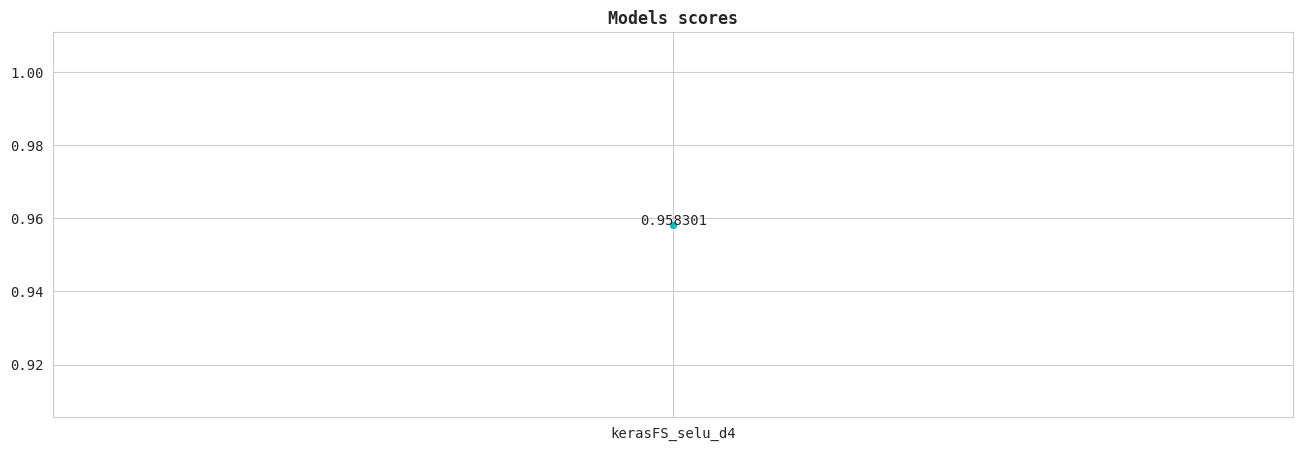

In [39]:
## -- Get Scores --
all_scores = {}

for k, v in all_predictions.items():
    for x, y in v.items():
        if x == "oof_score":
            all_scores[k] = y

plt.figure(figsize=(16, 5))
ax = sns.lineplot(all_scores, marker='o')

# ax.fill_between(range(len(all_model_scores)), all_model_scores.values(), alpha=0.1)
ax.set_title("Models scores", fontweight="semibold")
ax.tick_params('x', rotation=0)
# ax.set_ylim(0.96, 0.968)

add_ = 1e-5
for i, s in enumerate(all_scores.values()):
    ax.text(float(i), s+add_, s, ha="center", va="baseline")

# plt.tight_layout()
plt.show()

In [40]:
histories = {}
fold_scores = {}

for k, v in all_predictions.items():
    for x, y in v.items():
        if x == "history":
            histories[k] = y
        elif x == "fold_score":
            fold_scores[k] = y

fold_scores

{'kerasFS_selu_d4': [np.float64(0.9575682175138471),
  np.float64(0.9580784558599224),
  np.float64(0.9586090595165158),
  np.float64(0.9594365101486105),
  np.float64(0.9581041206535469)]}

In [41]:
# for i, (data, score) in tqdm(enumerate(zip(histories.values(), fold_scores.values()))):
#     print("Hist", data[i]['auc'])
#     print(score[i])
#     break

In [42]:
# ## -- Plot results --
# histories = {}

# for i, (k, v) in enumerate(all_predictions.items()):
#     for j, (x, y) in enumerate(v.items()):
#         if x == "history":
#             histories[k] = y
#             # print(y)
#             loss_results = pd.DataFrame({'train_loss': y[i]['loss'], 'val_loss': y[i]['val_loss']})
#             auc_results  = pd.DataFrame({'train_auc': y[i]['auc'], 'val_auc': y[i]['val_auc']})

#             plt.figure(figsize=(16, 5))
#             marker = 'o'

#             ## -- Plot LOSS --
#             plt.subplot(121)
#             sns.lineplot(loss_results, x=loss_results.index, y=loss_results.train_loss, label='train_loss', marker=marker)
#             sns.lineplot(loss_results, x=loss_results.index, y=loss_results.val_loss, label='val_loss', marker=marker)
#             plt.title(f"- LOSS -", fontweight='semibold')
#             plt.xlabel('Epochs')
#             plt.ylabel('Loss')
        
#             ## -- Plot AUC --
#             plt.subplot(122)
#             sns.lineplot(auc_results, x=auc_results.index, y=auc_results.train_auc, label='train_auc', marker=marker)
#             sns.lineplot(auc_results, x=auc_results.index, y=auc_results.val_auc, label='val_auc', marker=marker)
#             plt.title(f"- AUC -", fontweight='semibold')
#             plt.xlabel('Epochs')
#             plt.ylabel('AUC')
#             min_value = min(min(auc_results.train_auc)-1e-3, min(auc_results.val_auc-1e-3))
#             max_value = max(max(auc_results.train_auc+1e-3), max(auc_results.val_auc+1e-3))
#             plt.ylim((min_value, max_value))
        
#             stat_ = f"fold_auc: {fold_scores[k][i]:.6f}"
#             plt.scatter(x=0, y=0, label=stat_, color='g')
        
#             plt.suptitle(f"{k}: FOLD {i+1}", fontsize=15, fontweight='semibold')
#             plt.legend(loc='lower right')
#             plt.tight_layout()
#             plt.show()
        
#             print()
        
#             # break

In [43]:
# ## -- Plotting results --

# for i, (k, v) in enumerate(histories.items()):
#     print(k)
#     for j, (fold, score) in enumerate(zip(v, fold_score)):
#         loss_results = pd.DataFrame({'train_loss': fold['loss'], 'val_loss': fold['val_loss']})
#         auc_results = pd.DataFrame({'train_auc': fold['auc'], 'val_auc': fold['val_auc']})
#         plt.figure(figsize=(16, 5))
#         marker = 'o'
    
#         ## -- PLOT LOSS --
#         plt.subplot(121)
#         sns.lineplot(loss_results, x=loss_results.index, y=loss_results.train_loss, label='train_loss', marker=marker)
#         sns.lineplot(loss_results, x=loss_results.index, y=loss_results.val_loss, label='val_loss', marker=marker)
#         plt.title(f"{k} LOSS", fontweight='semibold')
#         plt.xlabel('Epochs')
#         plt.ylabel('Loss')
    
#         ## -- PLOT AUC --
#         plt.subplot(122)
#         sns.lineplot(auc_results, x=auc_results.index, y=auc_results.train_auc, label='train_auc', marker=marker)
#         sns.lineplot(auc_results, x=auc_results.index, y=auc_results.val_auc, label='val_auc', marker=marker)
#         plt.title(f"{k} AUC", fontweight='semibold')
#         plt.xlabel('Epochs')
#         plt.ylabel('AUC')
#         min_value = min(min(auc_results.train_auc)-1e-3, min(auc_results.val_auc-1e-3))
#         max_value = max(max(auc_results.train_auc+1e-3), max(auc_results.val_auc+1e-3))
#         plt.ylim((min_value, max_value))
    
#         stat_ = f"fold_auc: {score[j]:.6f}"
#         plt.scatter(x=0, y=0, label=stat_, color='y')
    
#         plt.suptitle(f"FOLD {j+1}", fontsize=15, fontweight='semibold')
#         plt.legend(loc='best')
#         plt.tight_layout()
#         plt.show()
#         print()

kerasFS_selu_d4_958301 saved!


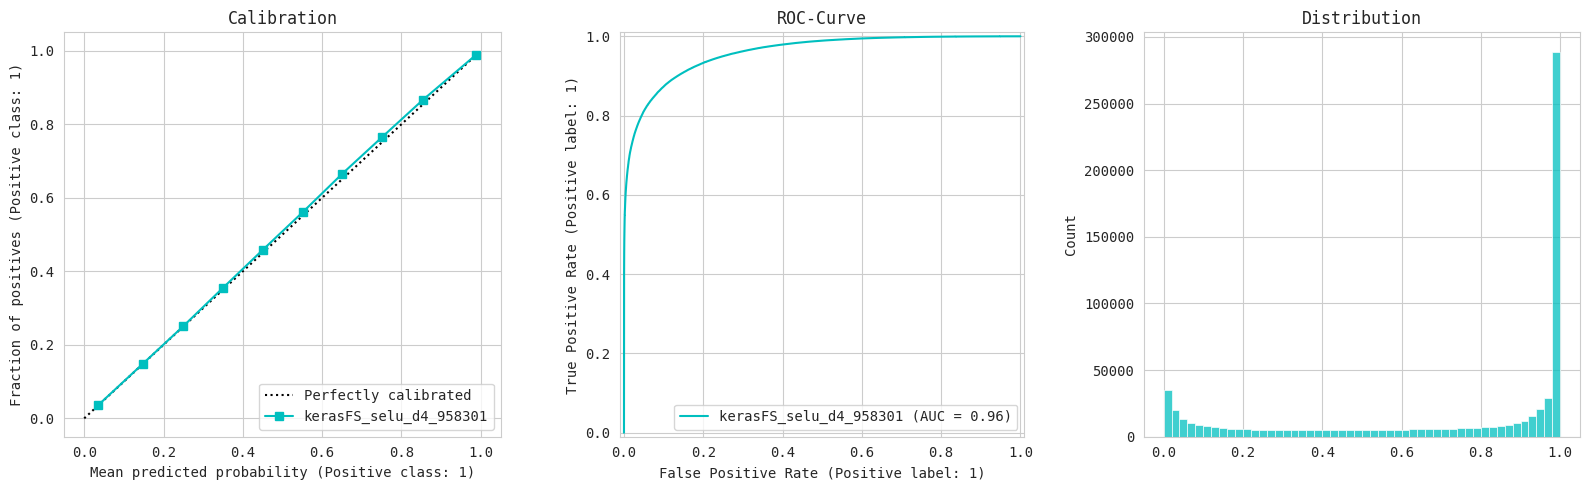

In [44]:
## -- Get oof predictions --

for i, (k, v) in enumerate(all_predictions.items()):
    for key_, data_ in v.items():
        if key_ == "oof_preds":
            ## -- Save oof predictions --
            n = f"{k}_{str(all_scores[k]).split('.')[1]}"
            np.save(f"oof_{n}.npy", data_)
            print(f"{n} saved!")

            ## -- Plot oof distributions --
            _, axs = plt.subplots(1, 3, figsize=(16, 5)) 
            CalibrationDisplay.from_predictions(train_data[TARGET], data_, n_bins=10, name=n, ax=axs[0])
            axs[0].set_title(f"Calibration")

            RocCurveDisplay.from_predictions(train_data[TARGET], data_, name=n, ax=axs[1])
            axs[1].set_title(f"ROC-Curve")

            sns.histplot(data_, ax=axs[2], bins=50)
            axs[2].set_title(f"Distribution")
            
            plt.tight_layout()
            plt.show()

            print()

In [45]:
## -- Save test predictions/submissions --
model_results = {}

for i, (k, v) in enumerate(all_predictions.items()):
    for j, (x, y) in enumerate(v.items()):
        if x == "test_preds":
            ## -- Base submission file --
            n = f"{k}_{str(all_scores[k]).split('.')[1]}"
            np.save(f"test_{n}.npy", y)

            submit[TARGET] = y
            submit.to_csv(f"submit_{n}.csv", index=False)
            print(f"{CFG['YELLOW']}{n}{CFG['RESET']} saved! {y.shape}")

            model_results[n[:-6]] = y

print()
model_results = pd.DataFrame(model_results)
model_results

kerasFS_selu_d4_958301 saved! (296302,)



,kerasFS_selu_d4_
0,0.998295
1,0.889192
2,0.942992
3,0.927692
4,0.990840
...,...
296297,0.999995
296298,0.951350
296299,0.166523
296300,0.869731


In [46]:
if len(model_results.columns) > 1:
    # display(model_results.corr("spearman"))
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
    sns.heatmap(model_results.corr("spearman"), annot=True, fmt=".4g", cbar=False, ax=ax1)
    ax1.set_title('Heatmap Correlation (Spearman)', fontsize=14, fontweight='bold')
    
    sns.ecdfplot(data=model_results, linewidth=2, ax=ax2)
    ax2.set_title('CDF Comparison of 5 Probability Distributions', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Probability Value', fontsize=12)
    ax2.set_ylabel('Cumulative Proportion (CDF)', fontsize=12)
    ax2.grid(True, linestyle='--', alpha=0.6)
    
    plt.tight_layout()
    plt.show()

In [47]:
# !rm -r /kaggle/working